# Section 1 : Imports et Dépendances

        On commence par charger toutes les bibliothèques nécessaires : PyTorch pour le Deep Learning, Torchvision pour le modèle ConvNeXt, et les outils de Data Science classiques.


In [ ]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

# Section 2 : Configuration & Hyperparamètres

    On centralise ici tous les réglages. C'est pratique si tes potes veulent tester   d'autres BATCH_SIZE ou changer le nombre d'époques sans chercher dans tout le code.

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Chemin vers le dataset Kaggle HAM10000
META_CSV = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'

# Hyperparamètres
BATCH_SIZE = 32
MAX_LR = 2e-4
EPOCHS = 15
MODEL_SAVE_PATH = 'best_melanoscan_v11.pth'

# Section 3 : Architecture MelanoScanV11
    C'est le cœur de l'IA. On utilise un modèle hybride :
        1-Backbone Image : ConvNeXt-Tiny (très efficace en vision).
        2-Branche Tabulaire : Un MLP pour traiter l'âge, le sexe et la zone du corps.
        3-Fusion : On concatène les deux pour la décision finale.

In [ ]:
# --- 2. ARCHITECTURE ---
class MelanoScanV11(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = models.convnext_tiny(weights="DEFAULT")
        img_features = self.backbone.classifier[2].in_features
        self.backbone.classifier = nn.Identity()
        
        self.mlp = nn.Sequential(
            nn.Linear(3, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(img_features + 64, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, img, tab):
        x = self.backbone(img)
        if x.dim() > 2:
            x = F.adaptive_avg_pool2d(x, (1, 1))
            x = torch.flatten(x, 1)
        tab_feat = self.mlp(tab)
        combined = torch.cat((x, tab_feat), dim=1)
        return self.classifier(combined)


# Section 4 : Préparation des Données & Loaders
    Ici, on gère :
        -Le chargement des images depuis le disque.
        -L'encodage des métadonnées (âge, sexe).
        -WeightedRandomSampler : Très important car il y a beaucoup plus de grains de beauté (nv) que de mélanomes. Ça force l'IA à voir autant de cas rares que de cas fréquents.

In [ ]:

# --- 3. DATA PREPARATION ---
def get_dataloaders():
    all_paths = {os.path.basename(x).split('.')[0]: x for x in glob.glob('/kaggle/input/**/*.jpg', recursive=True)}
    df = pd.read_csv(META_CSV)
    df = df[df['image_id'].isin(all_paths.keys())].reset_index(drop=True)
    
    df['age'] = df['age'].fillna(df['age'].median())
    df['age'] = (df['age'] - df['age'].mean()) / df['age'].std()
    df['sex_enc'] = LabelEncoder().fit_transform(df['sex'].fillna('unknown'))
    df['loc_enc'] = LabelEncoder().fit_transform(df['localization'].fillna('unknown'))
    
    label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
    df['target'] = df['dx'].map(label_map)
    
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['target'], random_state=42)

    class_counts = train_df['target'].value_counts().sort_index().values
    weights = 1. / class_counts
    samples_weights = [weights[t] for t in train_df['target']]
    sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

    # Augmentation plus forte pour la V11
    train_trans = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    val_trans = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    class SkinDataset(Dataset):
        def __init__(self, dataframe, transform):
            self.df = dataframe.reset_index(drop=True)
            self.transform = transform
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = self.transform(Image.open(all_paths[row['image_id']]).convert('RGB'))
            tab = torch.tensor([row['age'], row['sex_enc'], row['loc_enc']], dtype=torch.float32)
            return img, tab, row['target']

    train_loader = DataLoader(SkinDataset(train_df, train_trans), batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(SkinDataset(val_df, val_trans), batch_size=BATCH_SIZE, shuffle=False)
    
    return train_loader, val_loader

# Section 5 : Boucle d'entraînement (Training)
    On utilise OneCycleLR pour accélérer l'entraînement et le label_smoothing pour éviter que le modèle ne soit trop "sûr de lui" (ce qui aide à la généralisation).

In [ ]:
# --- 4. TRAINING LOOP ---
def train_v11():
    train_loader, val_loader = get_dataloaders()
    model = MelanoScanV11().to(DEVICE)
    
    # Label Smoothing pour aider la generalisation
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # AdamW avec un weight_decay plus eleve
    optimizer = optim.AdamW(model.parameters(), lr=MAX_LR/10, weight_decay=0.05)
    
    # Scheduler OneCycle pour une convergence rapide et propre
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=MAX_LR, 
        steps_per_epoch=len(train_loader), 
        epochs=EPOCHS
    )
    
    best_acc = 0
    print("Demarrage du Training V11 (Optimisation High-Accuracy)...")
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for imgs, tabs, labels in train_loader:
            imgs, tabs, labels = imgs.to(DEVICE), tabs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            out = model(imgs, tabs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            scheduler.step() # Mise a jour du LR par batch
            
            t_loss += loss.item()
        
        # Validation
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for imgs, tabs, labels in val_loader:
                imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
                out = model(imgs, tabs)
                preds.extend(torch.argmax(out, dim=1).cpu().numpy())
                targets.extend(labels.numpy())
        
        b_acc = balanced_accuracy_score(targets, preds)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {t_loss/len(train_loader):.4f} | B-Acc: {b_acc*100:.2f}% | LR: {current_lr:.6f}")
        
        if b_acc > best_acc:
            best_acc = b_acc
            torch.save(model.state_dict(), 'best_melanoscan_v11.pth')
            print("Nouveau record de Balanced Accuracy sauvegarde")

if __name__ == "__main__":
    train_v11()

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 202MB/s]  


Demarrage du Training V11 (Optimisation High-Accuracy)...
Epoch 1/15 | Loss: 1.6489 | B-Acc: 71.72% | LR: 0.000030
Nouveau record de Balanced Accuracy sauvegarde
Epoch 2/15 | Loss: 0.9542 | B-Acc: 80.73% | LR: 0.000087
Nouveau record de Balanced Accuracy sauvegarde
Epoch 3/15 | Loss: 0.7792 | B-Acc: 78.64% | LR: 0.000152
Epoch 4/15 | Loss: 0.7239 | B-Acc: 82.81% | LR: 0.000194
Nouveau record de Balanced Accuracy sauvegarde
Epoch 5/15 | Loss: 0.6726 | B-Acc: 82.17% | LR: 0.000199
Epoch 6/15 | Loss: 0.6264 | B-Acc: 85.49% | LR: 0.000190
Nouveau record de Balanced Accuracy sauvegarde
Epoch 7/15 | Loss: 0.6001 | B-Acc: 86.02% | LR: 0.000173
Nouveau record de Balanced Accuracy sauvegarde
Epoch 8/15 | Loss: 0.5665 | B-Acc: 87.29% | LR: 0.000150
Nouveau record de Balanced Accuracy sauvegarde
Epoch 9/15 | Loss: 0.5505 | B-Acc: 86.24% | LR: 0.000122
Epoch 10/15 | Loss: 0.5327 | B-Acc: 87.75% | LR: 0.000092
Nouveau record de Balanced Accuracy sauvegarde
Epoch 11/15 | Loss: 0.5144 | B-Acc: 87.24%

# Section 5bis : Optimisation par Test Time Augmentation (TTA)
    Le TTA est une technique qui consiste à montrer chaque image de test à l'IA plusieurs fois, mais avec de légères variations (rotations, flips).

    C'est comme si on demandait à un dermatologue(Expertise Clinique) de regarder un grain de beauté sous plusieurs angles avant de décider. On fait la moyenne des prédictions pour obtenir un résultat beaucoup plus stable et précis que sur une seule image fixe.

In [ ]:
import torch
from sklearn.metrics import balanced_accuracy_score, classification_report

def final_validation_with_tta(model_path, n_tta=10):
    print(f"Demarrage de la validation finale avec TTA sur : {model_path}")
    _, val_loader = get_dataloaders()
    
    model = MelanoScanV11().to(DEVICE)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # Augmentations pour le TTA
    tta_trans = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
    ])
    
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for imgs, tabs, labels in val_loader:
            imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
            
            # Faire n_tta prédictions pour chaque image
            batch_probs = []
            for _ in range(n_tta):
                aug_imgs = torch.stack([tta_trans(img) for img in imgs])
                outputs = model(aug_imgs, tabs)
                batch_probs.append(torch.softmax(outputs, dim=1))
            
            # Moyenne des probabilités (Ensemble interne)
            avg_probs = torch.stack(batch_probs).mean(0)
            preds = torch.argmax(avg_probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    final_b_acc = balanced_accuracy_score(all_targets, all_preds)
    print(f"\nRESULTAT FINAL AVEC TTA : {final_b_acc*100:.2f}%")
    print("\nRapport Detaille :")
    print(classification_report(all_targets, all_preds))

# Lancement sur ton nouveau fichier V11
final_validation_with_tta('best_melanoscan_v11.pth')

Demarrage de la validation finale avec TTA sur : best_melanoscan_v11.pth

RESULTAT FINAL AVEC TTA : 88.00%

Rapport Detaille :
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1341
           1       0.70      0.78      0.74       223
           2       0.88      0.77      0.82       220
           3       0.93      0.91      0.92       103
           4       0.72      0.91      0.80        65
           5       0.90      0.93      0.91        28
           6       0.88      0.91      0.89        23

    accuracy                           0.90      2003
   macro avg       0.85      0.88      0.86      2003
weighted avg       0.91      0.90      0.91      2003



# Section 6 : Visualisation des Performances (Matrice de Confusion)
    Pour comprendre non seulement si le modèle se trompe, mais surtout où il se trompe, on génère une matrice de confusion.

    Elle est normalisée (en %) pour voir d'un coup d'œil si, par exemple, le modèle a tendance à confondre les mélanomes (mel) avec les grains de beauté bénins (nv). On utilise une palette magma pour faire ressortir les scores élevés.

Demarrage de la validation TTA sur : best_melanoscan_v11.pth


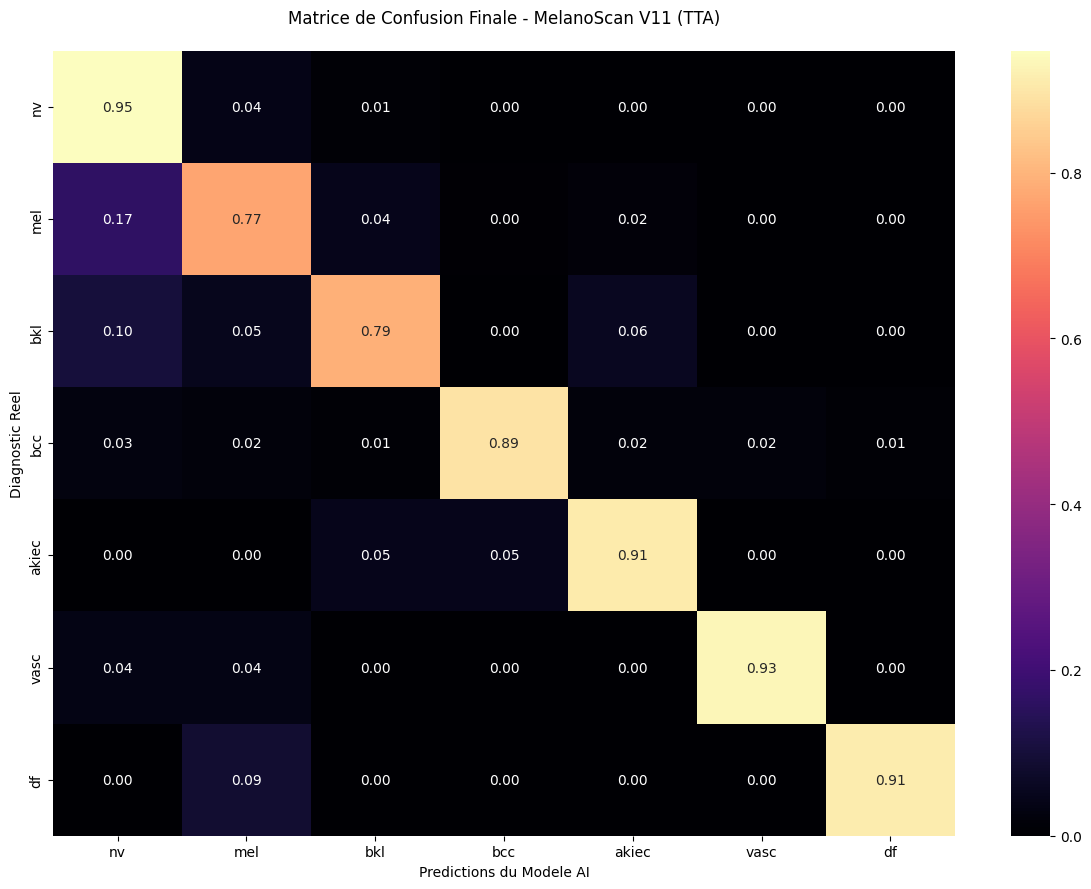


Balanced Accuracy Finale : 0.8781843956305605

Rapport Complet :
               precision    recall  f1-score   support

          nv       0.95      0.95      0.95      1341
         mel       0.72      0.77      0.74       223
         bkl       0.87      0.79      0.83       220
         bcc       0.93      0.89      0.91       103
       akiec       0.74      0.91      0.81        65
        vasc       0.90      0.93      0.91        28
          df       0.91      0.91      0.91        23

    accuracy                           0.91      2003
   macro avg       0.86      0.88      0.87      2003
weighted avg       0.91      0.91      0.91      2003



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, classification_report
from torchvision import transforms

# --- 1. FONCTION DE VALIDATION AVEC TTA ---
def evaluate_with_tta(model_path, n_augs=5):
    print(f"Demarrage de la validation TTA sur : {model_path}")
    
    # On recupere les donnees (Assure-toi que get_dataloaders() est definie avant)
    _, val_loader = get_dataloaders()
    
    # Initialisation du modele V11
    model = MelanoScanV11().to(DEVICE)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Definition des transformations pour le TTA
    tta_transforms = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
    ])

    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, tabs, labels in val_loader:
            imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
            
            # Faire plusieurs predictions par image
            multi_preds = []
            for _ in range(n_augs):
                augmented_imgs = torch.stack([tta_transforms(img) for img in imgs])
                outputs = model(augmented_imgs, tabs)
                multi_preds.append(torch.softmax(outputs, dim=1))
            
            # Moyenne des predictions
            final_outputs = torch.mean(torch.stack(multi_preds), dim=0)
            preds = torch.argmax(final_outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    return all_targets, all_preds

# --- 2. FONCTION DE DESSIN DE LA MATRICE ---
def plot_final_confusion_matrix(targets, preds):
    target_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
    cm = confusion_matrix(targets, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='magma',
                xticklabels=target_names, yticklabels=target_names)
    
    plt.title('Matrice de Confusion Finale - MelanoScan V11 (TTA)', pad=20)
    plt.xlabel('Predictions du Modele AI')
    plt.ylabel('Diagnostic Reel')
    plt.tight_layout()
    plt.savefig('Confusion_Matrix_Final.png', dpi=300)
    plt.show()

# --- 3. EXECUTION ---
# Assure-toi que 'best_melanoscan_v11.pth' existe bien dans ton repertoire courant
try:
    targets, preds = evaluate_with_tta('best_melanoscan_v11.pth')
    plot_final_confusion_matrix(targets, preds)
    
    print("\nBalanced Accuracy Finale :", balanced_accuracy_score(targets, preds))
    print("\nRapport Complet :\n", classification_report(targets, preds, target_names=['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']))
except Exception as e:
    print(f"Erreur lors de l'execution : {e}")